HISTOGRAMS
A histogram shows how a numeric variable is distributed by grouping values into ranges called bins and counting how many observations fall into each bin.
Use a histogram when you want to:
See the shape of the data (normal, skewed, bimodal)
Understand spread and variability
Detect outliers or gaps
Compare distributions (using multiple histograms or overlays)

When not to use a histogram:
For categorical data → use a bar chart
When exact individual values matter → use dot plots or tables
With very small datasets → histograms can be misleading

Each bin = score range (e.g., 70–80)
Bar height = number of students in that range
Shape tells you if scores cluster, skew, or split into groups

In [34]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
data = load_breast_cancer()
X = data.data        # features
print(data.feature_names)
y = data.target 

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

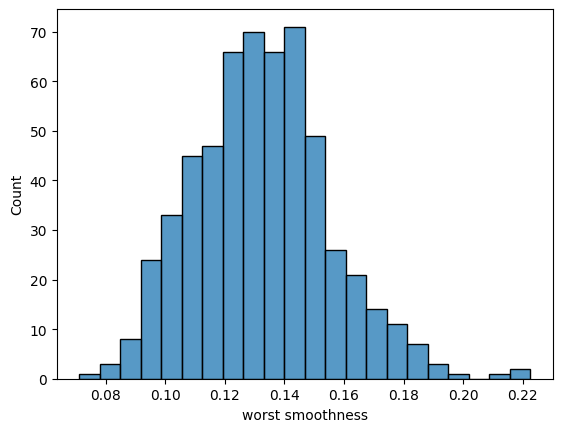

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(data=df, x="worst smoothness")
plt.show()

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [25]:
y_pred = model.predict(X_test)


In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9824561403508771
[[41  1]
 [ 1 71]]
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# predicted probabilities for malignant class (class 0)
y_probs = model.predict_proba(X_test)[:, 0]

fpr, tpr, thresholds = roc_curve(y_test, y_probs, pos_label=0)
auc_score = roc_auc_score(y_test, y_probs)

print("AUC:", auc_score)
